In [2]:
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from PIL import Image, ImageEnhance

# For ML Models
from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.models import *
from tensorflow.keras.metrics import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.applications import *
from tensorflow.keras.preprocessing.image import load_img

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
from tqdm import tqdm
import os
import random

In [47]:
train_dir = '/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/'
test_dir = '/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/'

train_paths = []
train_labels = []

for label in os.listdir(train_dir):
    for image in os.listdir(train_dir+label):
        train_paths.append(train_dir+label+'/'+image)
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

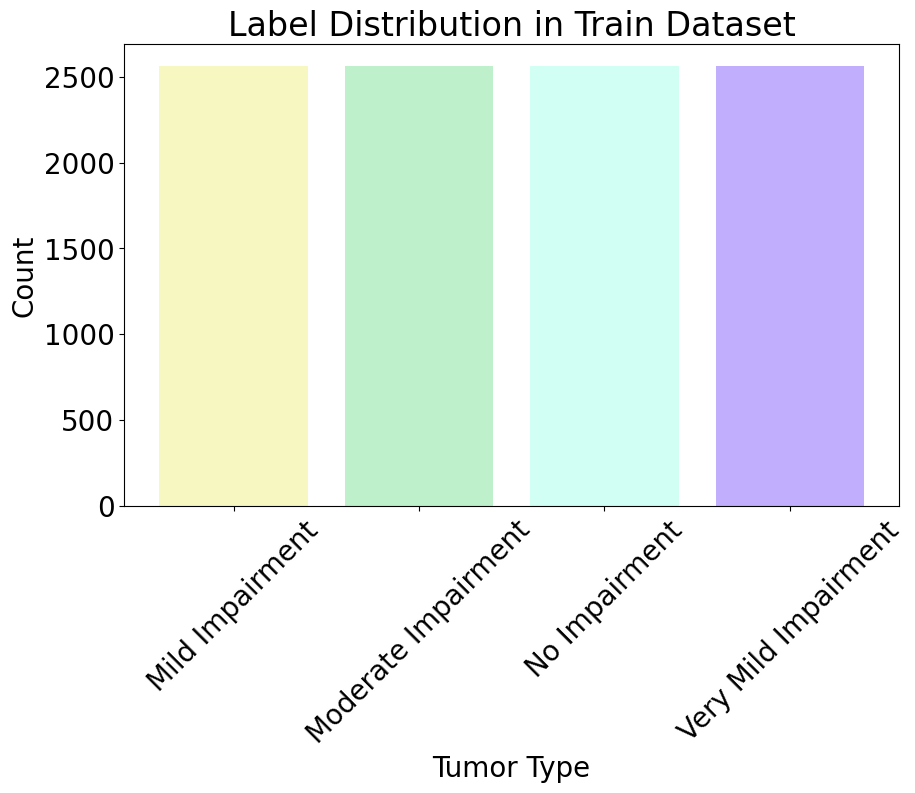

In [48]:
labels = ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
counts = [
    len([x for x in train_labels if x == 'Mild Impairment']),
    len([x for x in train_labels if x == 'Moderate Impairment']),
    len([x for x in train_labels if x == 'No Impairment']),
    len([x for x in train_labels if x == 'Very Mild Impairment'])
]

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color=['#F6F7C1', '#BEF0CB', '#D1FFF3', '#C1AEFC'])
plt.title('Label Distribution in Train Dataset')
plt.ylabel('Count')
plt.xlabel('Tumor Type')
plt.xticks(rotation=45)
plt.show()

In [49]:
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    for image in os.listdir(test_dir+label):
        test_paths.append(test_dir+label+'/'+image)
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

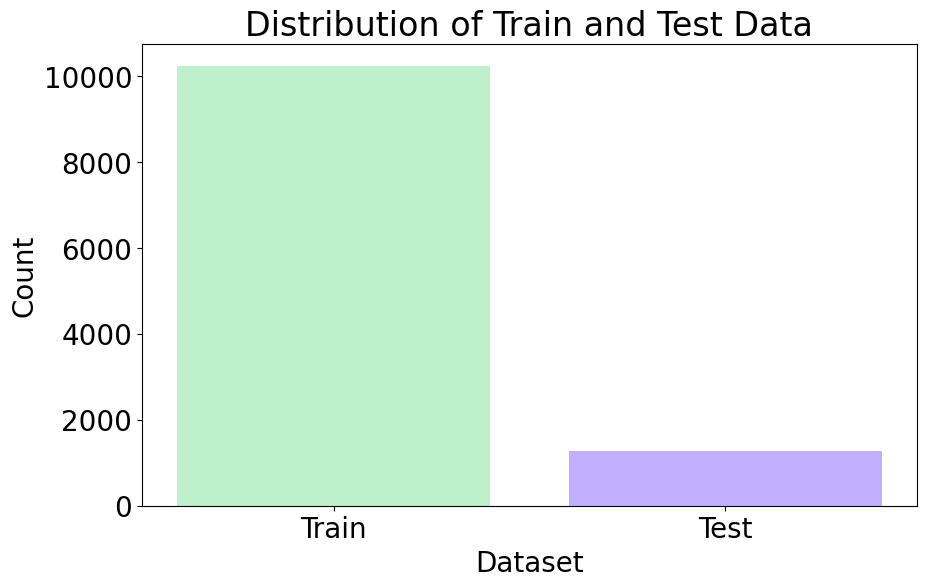

In [50]:
# Counts of train and test datasets
data_labels = ['Train', 'Test']
data_counts = [len(train_labels), len(test_labels)]

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(data_labels, data_counts, color=['#BEF0CB', '#C1AEFC'])
plt.title('Distribution of Train and Test Data')
plt.ylabel('Count')
plt.xlabel('Dataset')
plt.show()


In [51]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
    image = np.array(image)/255.0
    return image

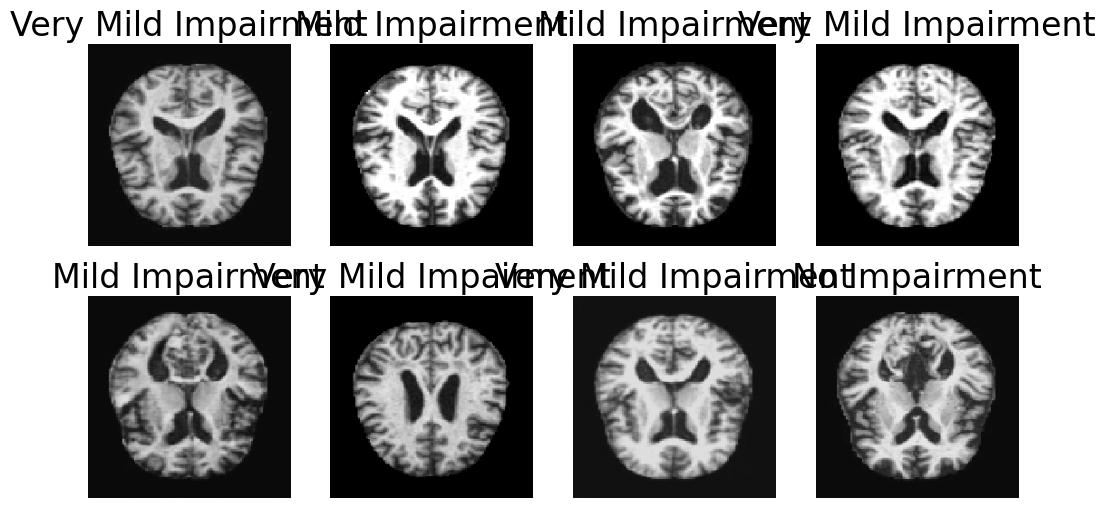

In [52]:
IMAGE_SIZE = 224

def open_images(paths):
    '''
    Given a list of paths to images, this function returns the images as arrays (after augmenting them)
    '''
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE,IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

images = open_images(train_paths[50:59])
labels = train_labels[50:59]
fig = plt.figure(figsize=(12, 6))
for x in range(1, 9):
    fig.add_subplot(2, 4, x)
    plt.axis('off')
    plt.title(labels[x])
    plt.imshow(images[x])
plt.rcParams.update({'font.size': 20})
plt.show()

In [54]:
unique_labels = os.listdir(train_dir)

from tensorflow.keras.utils import to_categorical

def encode_label(labels):
    # Convert labels to integers and then one-hot encode them
    encoded = [unique_labels.index(label) for label in labels]
    return to_categorical(encoded, num_classes=len(unique_labels))


def decode_label(labels):
    decoded = []
    for x in labels:
        decoded.append(unique_labels[x])
    return np.array(decoded)

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for x in range(0, len(paths), batch_size):
            batch_paths = paths[x:x+batch_size]
            batch_images = open_images(batch_paths)  # Load and augment images
            batch_labels = labels[x:x+batch_size]
            batch_labels = encode_label(batch_labels)  # Ensure labels are one-hot encoded
            yield batch_images, batch_labels

In [55]:
unique_labels

['No Impairment',
 'Very Mild Impairment',
 'Moderate Impairment',
 'Mild Impairment']

In [56]:


# Define the input shape
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense

# Define the input image size
IMAGE_SIZE = 224  # Replace with your desired image size
num_classes = len(unique_labels)  # Adjust to the number of unique labels

# Load the ResNet50 base model
base_model = ResNet50(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Set all layers to non-trainable
for layer in base_model.layers:
    layer.trainable = False

# Optionally fine-tune the last few layers of ResNet50
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(GlobalAveragePooling2D())  # Global pooling layer
model.add(Dropout(0.3))  # Dropout for regularization
model.add(Dense(128, activation='relu'))  # Fully connected layer
model.add(Dropout(0.2))  # Dropout for regularization
model.add(Dense(num_classes, activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # Use 'sparse_categorical_crossentropy' if labels are not one-hot encoded
    metrics=['accuracy']
)

# Summary of the model
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 1,317,508 (5.03 MB)

 Non-trainable params: 22,532,992 (85.96 MB)

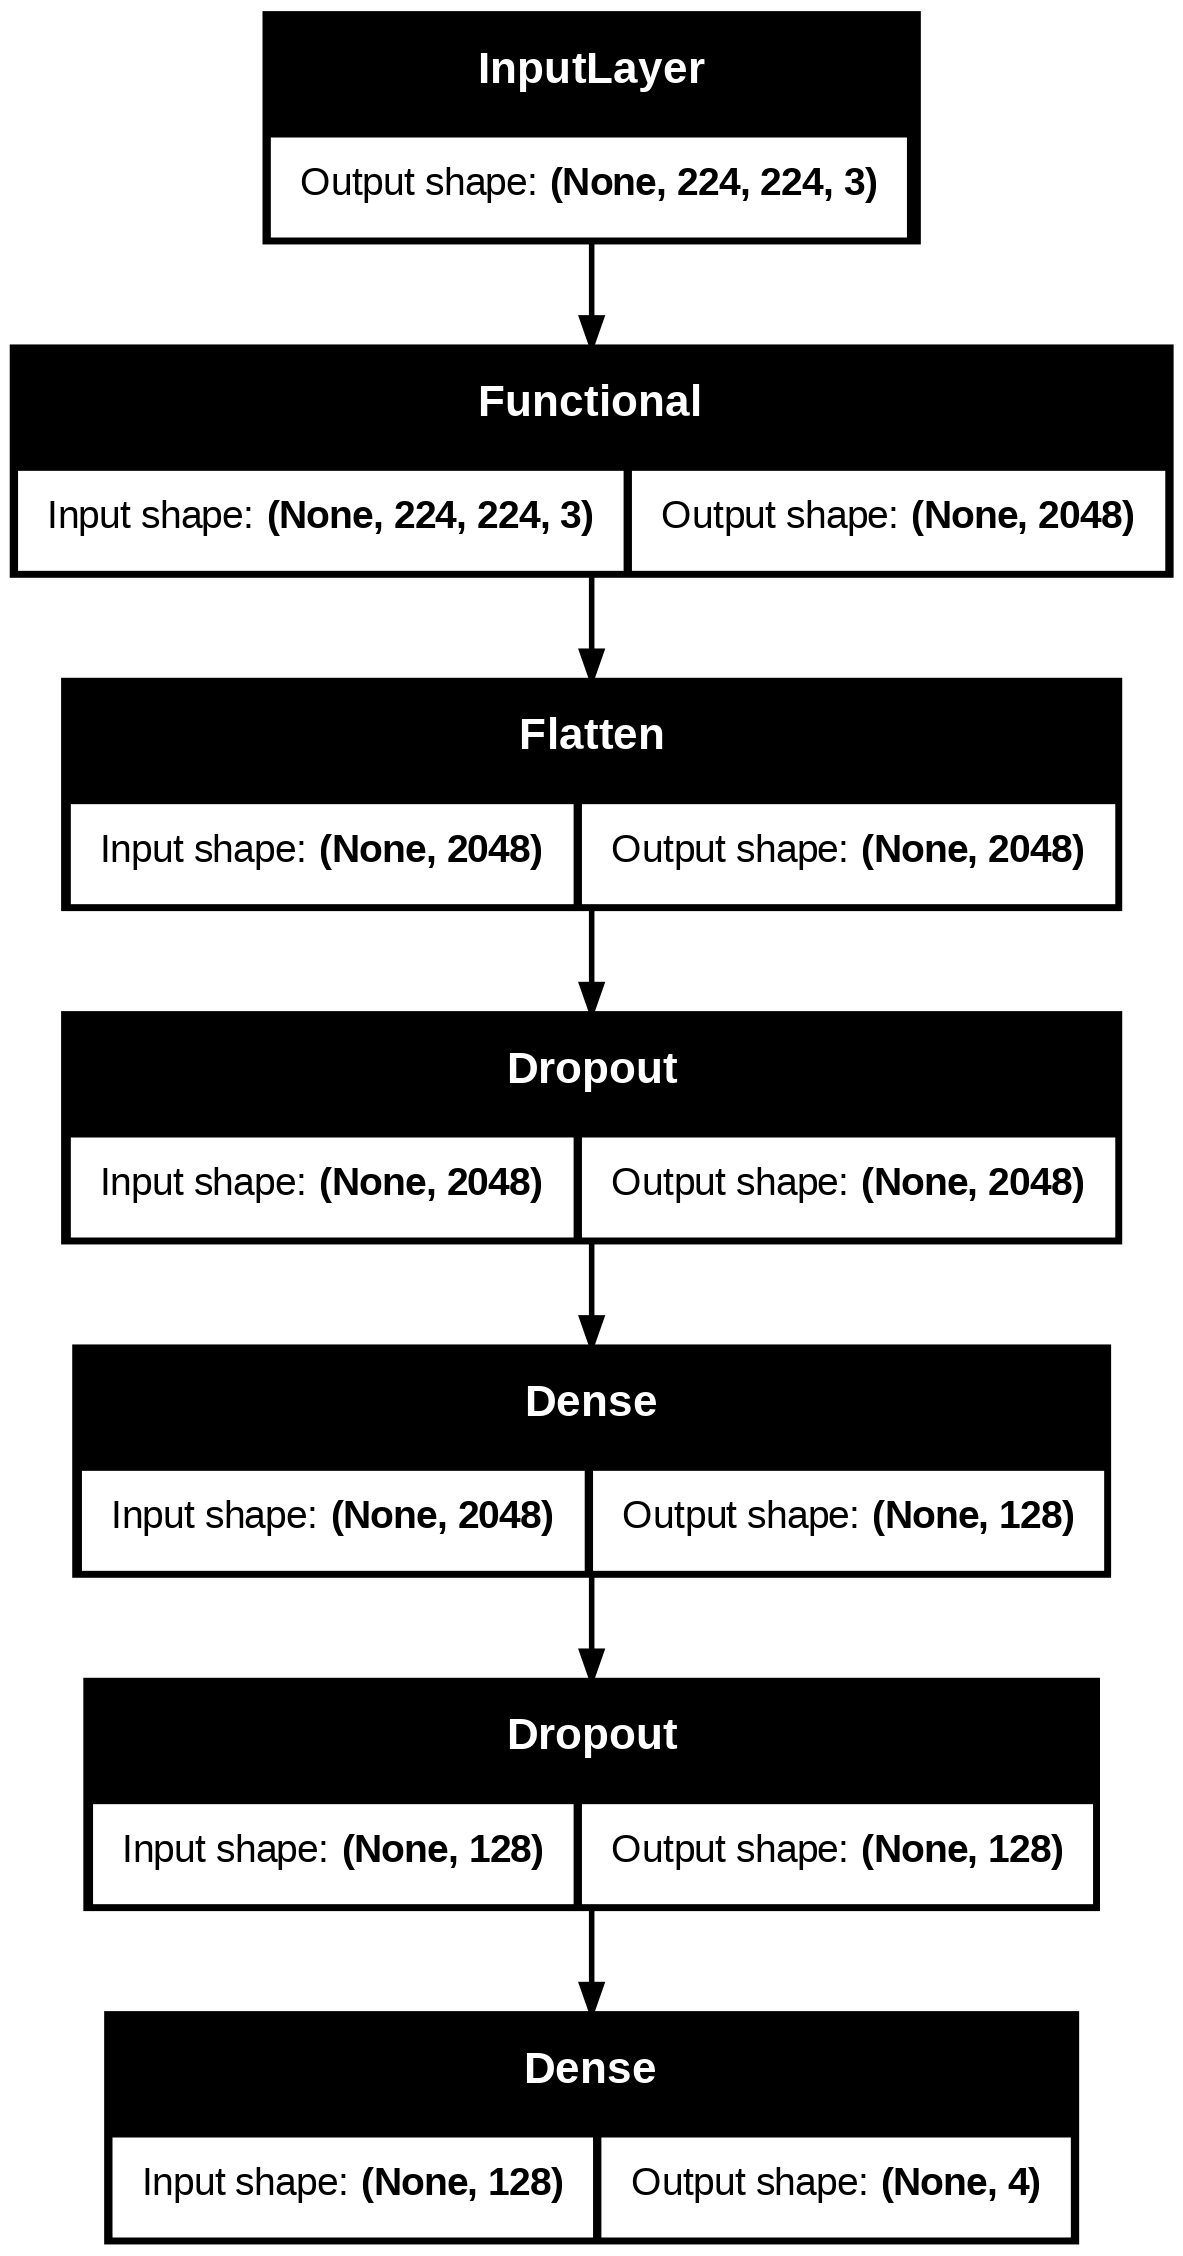

In [20]:
keras.utils.plot_model(model, show_shapes=True)

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
device_name = tf.test.gpu_device_name()
if device_name:
    print(f"Using GPU: {device_name}")
else:
    print("GPU is not available. Ensure GPU is enabled in Kaggle settings.")

# Training parameters
batch_size = 20
steps = len(train_paths) // batch_size
epochs = 10

# Callbacks for better training
checkpoint = ModelCheckpoint(
    'alzheimer_best_model.keras', save_best_only=True, monitor='val_loss', mode='min'
)
early_stopping = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

# Start training
history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps,
    validation_data=datagen(test_paths, test_labels, batch_size=batch_size, epochs=epochs),
    validation_steps=len(test_paths) // batch_size,
    callbacks=[checkpoint, early_stopping]
)


Using GPU: /device:GPU:0
Epoch 1/10
512/512 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - accuracy: 0.5338 - loss: 1.0316 - val_accuracy: 0.4964 - val_loss: 0.9648
Epoch 3/10
512/512 ━━━━━━━━━━━━━━━━━━━━ 36s 70ms/step - accuracy: 0.5878 - loss: 0.9235 - val_accuracy: 0.5004 - val_loss: 1.0452
Epoch 4/10
503/512 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6010 - loss: 0.8742